In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

In [2]:
# Load and resize image to 256x256
image_path = '../../input.jpg'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print("Error: Could not load image")
else:
    sample_image = cv2.resize(original_image, (256, 256))
    print("Image loaded and resized to 256x256")

Image loaded and resized to 256x256


In [3]:
# Define line detection masks
horizontal_mask = np.array([[-1, -1, -1],
                            [ 2,  2,  2],
                            [-1, -1, -1]], dtype=np.float32)

vertical_mask = np.array([[-1,  2, -1],
                          [-1,  2, -1],
                          [-1,  2, -1]], dtype=np.float32)

diagonal_mask = np.array([[ 2, -1, -1],
                          [-1,  2, -1],
                          [-1, -1,  2]], dtype=np.float32)

# Apply convolution
horizontal_lines = ndimage.convolve(sample_image.astype(np.float32), horizontal_mask)
vertical_lines = ndimage.convolve(sample_image.astype(np.float32), vertical_mask)
diagonal_lines = ndimage.convolve(sample_image.astype(np.float32), diagonal_mask)

# Take absolute value and convert to uint8
horizontal_lines = np.abs(horizontal_lines).astype(np.uint8)
vertical_lines = np.abs(vertical_lines).astype(np.uint8)
diagonal_lines = np.abs(diagonal_lines).astype(np.uint8)

print("Line detection applied")

Line detection applied


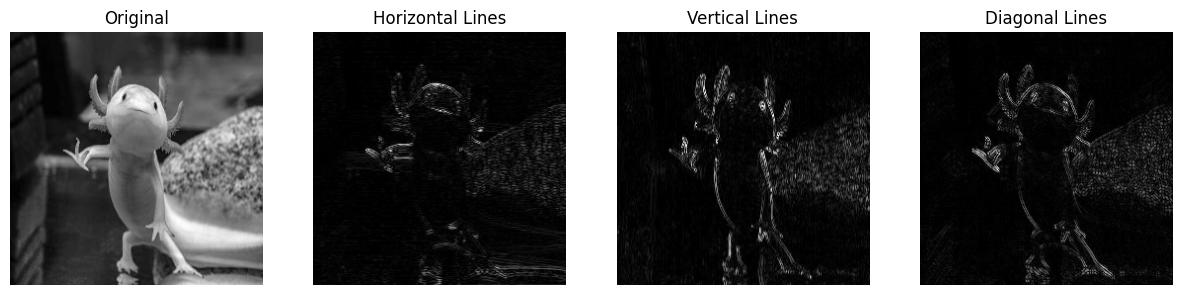

In [4]:
# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(sample_image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(horizontal_lines, cmap='gray')
plt.title('Horizontal Lines')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(vertical_lines, cmap='gray')
plt.title('Vertical Lines')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(diagonal_lines, cmap='gray')
plt.title('Diagonal Lines')
plt.axis('off')

plt.show()